Eğitim Setindeki Sağlıklı (Normal) Röntgen Sayısı: 1341
Eğitim Setindeki Zatürre (Pneumonia) Röntgen Sayısı: 3875


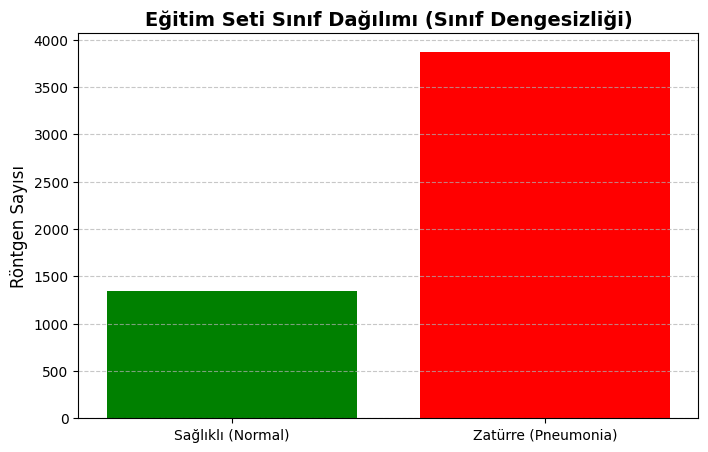

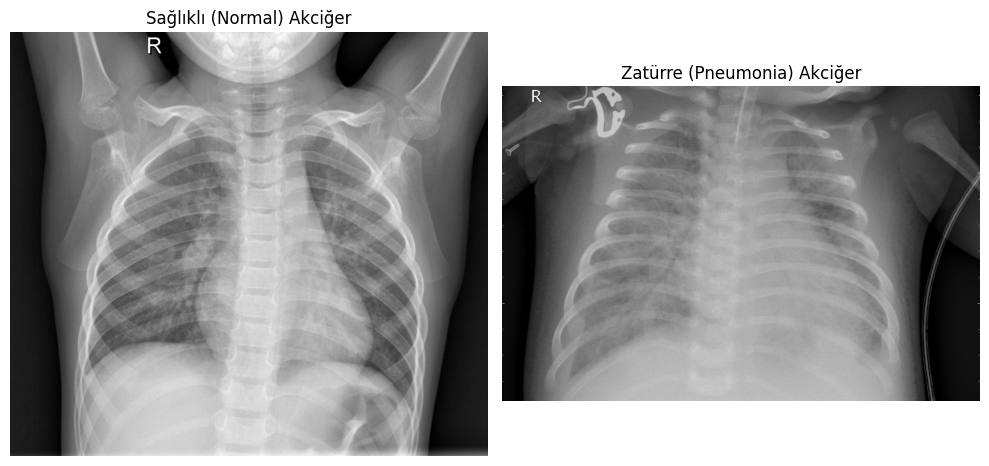

In [1]:
# =====================================================================
# BÖLÜM 1: KÜTÜPHANELERİN YÜKLENMESİ VE VERİ YOLLARININ BELİRLENMESİ
# =====================================================================

# os: İşletim sistemiyle iletişim kurmamızı ve klasörlerde gezinmemizi sağlar.
import os 

# pyplot: Ekrana grafik ve resim çizdirmek  için kullanıyoruz 
import matplotlib.pyplot as plt 

# mpimg: Bilgisayardaki resim dosyasını okuyup sayısal (piksel) matrislere çevirir.
import matplotlib.image as mpimg 

# os.path.join(): Klasör yollarını (işletim sistemine uygun şekilde) hatasız birleştirir.
train_dir = '../data/train'
normal_dir = os.path.join(train_dir, 'NORMAL')
pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')


# =====================================================================
# BÖLÜM 2: VERİ SAYILARININ HESAPLANMASI VE EKRANA YAZDIRILMASI ( eğitim verisi için )
# =====================================================================

# os.listdir(): Belirtilen klasörün içindeki tüm resim dosyalarının isimlerini bir liste olarak getirir.
# len(): Bu listenin uzunluğunu sayar. Sınıf dengesizliğini (imbalance) görmek için bunu kullanıyoruz.
normal_sayisi = len(os.listdir(normal_dir))   # normal olan  resimlerin sayısını hesaplıyor
zaturre_sayisi = len(os.listdir(pneumonia_dir))  # zature olan resimlerin  sayısını hesaplıyor 

print("Eğitim Setindeki Sağlıklı (Normal) Röntgen Sayısı:", normal_sayisi) # sayılarını ekrana bastırıyoruz 
print("Eğitim Setindeki Zatürre (Pneumonia) Röntgen Sayısı:", zaturre_sayisi)



# =====================================================================
# BÖLÜM 3: SINIF DAĞILIMININ ÇUBUK GRAFİĞİ İLE GÖRSELLEŞTİRİLMESİ
# =====================================================================

# X eksenindeki sınıf isimleri ve Y eksenindeki sayılar (1341 ve 3875)
siniflar = ['Sağlıklı (Normal)', 'Zatürre (Pneumonia)']
sayilar = [normal_sayisi, zaturre_sayisi]

# 8x5  boyutunda bir grafik alanı  açıyoruz
plt.figure(figsize=(8, 5))

# Çubuk grafiğini çizdiriyoruz (Sağlıklı: Yeşil, Zatürre: Kırmızı)
plt.bar(siniflar, sayilar, color=['green', 'red'])


# Grafiği rapor için isimlendiriyoruz
plt.title('Eğitim Seti Sınıf Dağılımı (Sınıf Dengesizliği)', fontsize=14, fontweight='bold')
plt.ylabel('Röntgen Sayısı', fontsize=12)

# Arka plana okunabilirliği artıran yatay kesik çizgiler ekliyoruz
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# =====================================================================
# BÖLÜM 4: ÖRNEK RÖNTGEN GÖRÜNTÜLERİNİN EKRANA ÇİZDİRİLMESİ
# =====================================================================

# listdir()[0]: Klasördeki resim listesinin ilk elemanını (0. indeks) yani ilk resmi seçeriz.
normal_ilk_resim = os.listdir(normal_dir)[0]
zaturre_ilk_resim = os.listdir(pneumonia_dir)[0]

# mpimg.imread(): Seçilen resmi okur ve bilgisayarın anlayacağı 0-255 arası piksel değerlerinden oluşan bir matrise dönüştürür.
img_normal = mpimg.imread(os.path.join(normal_dir, normal_ilk_resim))
img_zaturre = mpimg.imread(os.path.join(pneumonia_dir, zaturre_ilk_resim))

# plt.subplots(1, 2): 1 satır ve 2 sütundan oluşan, yan yana duran iki adet boş grafik alanı açar.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# imshow(): imread ile elde edilen piksel matrisini tekrar görsele çevirip ekrana basar.
# cmap='gray': Resmin siyah-beyaz (röntgen formatında) çizdirilmesini sağlar ki model sadece yapıya odaklansın.
axes[0].imshow(img_normal, cmap='gray')
axes[0].set_title('Sağlıklı (Normal) Akciğer')

# axis('off'): Resmin etrafındaki X ve Y eksenindeki sayıları (koordinatları) gizler, temiz görüntü sağlar.
axes[0].axis('off') 

axes[1].imshow(img_zaturre, cmap='gray')
axes[1].set_title('Zatürre (Pneumonia) Akciğer')
axes[1].axis('off')

# plt.tight_layout(): İki resmin başlıklarının ve çerçevelerinin birbirine girmesini engeller.
plt.tight_layout()

# plt.show(): Hazırlanan tüm grafikleri kullanıcıya (ekrana) yansıtır.
plt.show()

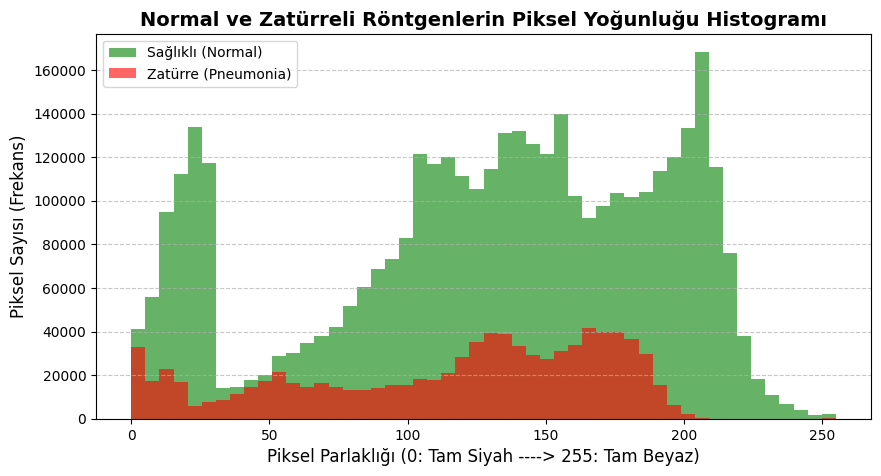

In [2]:
# ---------------------------------------------------------
# ADIM 5: PİKSEL YOĞUNLUĞU HİSTOGRAMI (Histogram Analysis)
# ---------------------------------------------------------
import numpy as np

# Önceki hücrelerde okuduğumuz img_normal ve img_zaturre matrislerini kullanıyoruz.
# Resimler 2 boyutlu (X, Y) olduğu için, pikselleri sayabilmek adına ravel() ile tek boyutlu bir listeye (1D) düzleştiriyoruz.
pixels_normal = img_normal.ravel()
pixels_zaturre = img_zaturre.ravel()

# Yeni bir grafik alanı açıyoruz
plt.figure(figsize=(10, 5))

# Sağlıklı resmin piksellerini yeşil, zatürreli resmin piksellerini kırmızı çizdiriyoruz.
# bins=50: Pikselleri 50 farklı ton grubuna ayırır. alpha=0.6: Grafikleri şeffaflaştırarak kesişimleri gösterir.
plt.hist(pixels_normal, bins=50, alpha=0.6, color='green', label='Sağlıklı (Normal)')
plt.hist(pixels_zaturre, bins=50, alpha=0.6, color='red', label='Zatürre (Pneumonia)')

# Grafiği rapor için isimlendiriyoruz
plt.title('Normal ve Zatürreli Röntgenlerin Piksel Yoğunluğu Histogramı', fontsize=14, fontweight='bold')
plt.xlabel('Piksel Parlaklığı (0: Tam Siyah ----> 255: Tam Beyaz)', fontsize=12)
plt.ylabel('Piksel Sayısı (Frekans)', fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 1. Keşfedici Veri Analizi (EDA) ve Veri Setinin Anatomisi

Projenin bu ilk aşamasında, *Chest X-Ray Images (Pneumonia)* veri setimizin eğitim klasörünü detaylıca inceledik. Çizdirdiğimiz grafiklerin ve elde ettiğimiz bulguların arka planındaki temel mantık şu şekildedir:

**1. Sayılar Bize Ne Söylüyor? (Sınıf Dengesizliği ve Yapay Zekanın Tembelliği)**
Yazdığımız kodla klasörlerdeki resimleri saydırdık ve şu sonuçlara ulaştık:
*   **Sağlıklı (Normal) Akciğer:** 1.341 adet 
*   **Zatürre (Pneumonia) Akciğer:** 3.875 adet

Bu sayılar veri setimizde yaklaşık 1'e 3 oranında çok ciddi bir "sınıf dengesizliği (class imbalance)" olduğunu gösteriyor. Yapay zeka modelleri tembeldir; eğer modeli bu sayılarla doğrudan eğitirsek, model görüntüdeki özellikleri öğrenmek yerine istatistiksel olarak kolaya kaçacaktır. Gördüğü her yeni röntgene sırf çoğunlukta olduğu için "Zatürre" deme eğilimi (bias/yanlılık) geliştirecek ve bizi yüksek ama sahte bir başarı oranıyla kandıracaktır. Modelin gerçekten öğrenmesi için bu sayısal uçurumu çözmemiz şarttır.

**2. Gözümüzle Gördüğümüz Fark (Örnek Röntgenlerin Mantığı)**
Ekrana çizdirdiğimiz iki farklı örnek röntgene baktığımızda, hastalığın ciğerde yarattığı fiziksel değişimi doğrudan görebiliyoruz:
*   Sağlıklı bir ciğerin içi tamamen **havayla** doludur. Röntgen ışınları bu havadan hiçbir engele takılmadan doğrudan geçtiği için, ortaya çıkan filmde ciğerin içi **siyah ve karanlık** bir görüntü oluşturur.
*   Zatürreli bir ciğerin içi ise hava değil; **iltihap, enfeksiyon ve sıvıyla** doludur. Bu sıvılar röntgen ışınlarının geçişini engeller. Bu nedenle filmde karanlık bölgeler yerine **puslu, bulutumsu ve beyaz lekeler (opasite)** ortaya çıkar. Bizim gözümüzle gördüğümüz bu fark, aslında modelin odaklanması gereken hedeftir.

3. Yapay Zekanın Gördüğü Fark (Piksel Yoğunluğu Histogramı)
Bilgisayar ekranındaki her resim on binlerce minicik kareden, yani pikselden oluşur. Yapay zekanın gözü yoktur; o sadece bu piksellerin parlaklık numaralarını okur. Bu numaralar 0 (zifiri siyah) ile 255 (bembeyaz) arasında değişir. Çizdirdiğimiz histogram grafiği, aslında sadece bir "sayım memuru" gibi çalışarak resimdeki siyah, gri ve beyaz noktaların adetlerini saymıştır:

Yeşil Dağlar (Sağlıklı Ciğerler): Grafiğin sol tarafına, yani 0'a (karanlık tonlara) yığılmıştır. Bu, "benim içimde çok fazla siyah nokta var çünkü içim hava dolu" demektir.

Kırmızı Dağlar (Zatürreli Ciğerler): Grafiğin en solunda pek bulunmazlar. İltihaplı sıvıların yarattığı puslu görüntü nedeniyle, kırmızı tepeler grafiğin orta ve sağ tarafına, yani gri ve beyaz tonlara (255'e doğru) kaymıştır.

Grafikteki Kritik Mühendislik Bulgusu (Neden Yeşil Dağ Devasa?)
Histograma dikkatli bakıldığında çok önemli bir veri problemi göze çarpmaktadır: Yeşil alan, kırmızı alanı boyut olarak tamamen ezmiş durumdadır ve sağlıklı (yeşil) grafikte de beyaz tonlarda (150-200 arası) ciddi yükselmeler vardır. Bu durumun iki teknik sebebi vardır:

Farklı Çözünürlükler (Görüntü Boyutları): Veri setindeki ham röntgenler aynı makineden çıkmadığı için standart bir boyutta değildir. Rastgele seçtiğimiz sağlıklı röntgen yüksek çözünürlüklü (milyonlarca piksel) devasa bir resimken, zatürreli röntgen çok daha düşük çözünürlüklü küçük bir resimdir. Histogram sadece toplam piksel sayısını hesapladığı için bu boyut farkı grafikteki dağların büyüklüğüne doğrudan yansımıştır.

Anatomik Yapılar (Kemikler ve Kalp): Röntgende sadece ciğerdeki hava boşlukları yer almaz; kaburgalar, köprücük kemikleri ve kalp kası da bulunur. Kemikler röntgen filminde parlak beyaz (200-255 arası) çıkar. Yüksek çözünürlüklü sağlıklı röntgenimizde çok daha fazla piksel olduğu için, içindeki kemik piksellerinin sayısı da fazladır ve bu durum yeşil grafiğin parlak/beyaz bölgelerde de tepe yapmasına yol açmıştır.

Özet ve Çözüm:
Bu histogram projenin hem matematiksel ispatı hem de bir uyarıcısıdır. Kuracağımız model, ciğerdeki iltihabın yarattığı bu "siyah piksellerden parlak piksellere doğru kayma" durumunu sayısal olarak ezberleyecek ve hastalığı bu numaralar üzerinden tespit edecektir. Ancak, grafikte kendi gözlerimizle tespit ettiğimiz boyut farkı sorununu çözmezsek, yapay zeka hastalığı öğrenmek yerine "Büyük çözünürlüklü resimler sağlıklı, küçük resimler zatürredir" şeklinde saçma bir ezber yapacaktır. Bu yüzden modeli kurmadan önce (Veri Ön İşleme aşamasında) tüm resimleri eşit ve standart bir boyuta (örneğin 224x224) getirmemiz (Resizing) teknik bir zorunluluktur.